# Feed Forward Neural Network (FFNN)

> Implementación y entrenamiento de una red neuronal *feed-forward* (Multi-Layer Perceptron) con **TensorFlow / Keras** sobre el dataset **MNIST** de dígitos manuscritos.

*Basado en las diapositivas `02a_Neural Networks.pdf` (sección Feed Forward NN, págs. 26–38).*

## 1. Descripción

Una **Feed Forward Neural Network (FFNN)** —también llamada **Multi-Layer Perceptron (MLP)**— es un modelo de aprendizaje supervisado inspirado en las neuronas biológicas. La información fluye en **una sola dirección** (de la entrada hacia la salida, sin ciclos ni retroalimentación), de ahí el nombre *feed-forward*.

La red se organiza en **capas**:

- **Capa de entrada** (*input*): recibe el vector de características $x \in \mathbb{R}^m$.
- **Capas ocultas** (*hidden*): combinaciones lineales de la capa previa seguidas de una **función de activación** no lineal $g(\cdot)$.
- **Capa de salida** (*output*): produce la predicción $\hat{y}$.

La activación de la neurona $i$ en la capa $k$ se calcula como (diapositiva pág. 30):

$$z_{k,i} = w_{0,i}^{(k)} + \sum_{j=1}^{n_{k-1}} g\!\left(z_{k-1,j}\right)\, w_{j,i}^{(k)}$$

donde $w_{0,i}^{(k)}$ es el **sesgo** (bias, $w_{j0}$ en las diapositivas) y $w_{j,i}^{(k)}$ son los **pesos**. Al apilar varias capas ocultas se obtiene una **Deep Feed Forward Neural Network (DFFNN)**.

### ¿Qué problema resuelve?
Una FFNN es un **aproximador universal de funciones**: con suficientes neuronas puede aproximar cualquier función continua. Se usa para:

- **Clasificación** (multiclase / binaria) — *este notebook*.
- **Regresión** (predicción de valores continuos).
- Extracción de representaciones para otras tareas.

### Caso de uso de este notebook
Clasificar imágenes de **dígitos manuscritos (0–9)** del dataset **MNIST**: cada imagen de $28\times28$ píxeles se aplana a un vector de $784$ valores en el rango $[0,1]$ que alimenta la red.

## 2. Bibtex y Referencias

### BibTeX
```bibtex
@article{rumelhart1986learning,
  title   = {Learning representations by back-propagating errors},
  author  = {Rumelhart, David E. and Hinton, Geoffrey E. and Williams, Ronald J.},
  journal = {Nature},
  volume  = {323},
  number  = {6088},
  pages   = {533--536},
  year    = {1986},
  publisher = {Nature Publishing Group}
}

@article{rosenblatt1958perceptron,
  title   = {The perceptron: A probabilistic model for information storage and organization in the brain},
  author  = {Rosenblatt, Frank},
  journal = {Psychological Review},
  volume  = {65},
  number  = {6},
  pages   = {386--408},
  year    = {1958},
  publisher = {American Psychological Association}
}

@article{lecun1998gradient,
  title   = {Gradient-based learning applied to document recognition},
  author  = {LeCun, Yann and Bottou, L{\'e}on and Bengio, Yoshua and Haffner, Patrick},
  journal = {Proceedings of the IEEE},
  volume  = {86},
  number  = {11},
  pages   = {2278--2324},
  year    = {1998},
  publisher = {IEEE}
}

@inproceedings{kingma2015adam,
  title     = {Adam: A method for stochastic optimization},
  author    = {Kingma, Diederik P. and Ba, Jimmy},
  booktitle = {3rd International Conference on Learning Representations (ICLR)},
  year      = {2015}
}

@article{srivastava2014dropout,
  title   = {Dropout: A simple way to prevent neural networks from overfitting},
  author  = {Srivastava, Nitish and Hinton, Geoffrey and Krizhevsky, Alex and Sutskever, Ilya and Salakhutdinov, Ruslan},
  journal = {Journal of Machine Learning Research},
  volume  = {15},
  number  = {1},
  pages   = {1929--1958},
  year    = {2014}
}
```

### APA
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature, 323*(6088), 533–536.
- Rosenblatt, F. (1958). The perceptron: A probabilistic model for information storage and organization in the brain. *Psychological Review, 65*(6), 386–408.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278–2324.
- Kingma, D. P., & Ba, J. (2015). *Adam: A method for stochastic optimization*. In 3rd International Conference on Learning Representations (ICLR).
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(1), 1929–1958.

## 3. Tipo de Modelo

| Criterio | Clasificación |
|---|---|
| **Método de aprendizaje** | Supervisado (cada imagen tiene su etiqueta 0–9) |
| **Por parámetros** | Paramétrico (número fijo de pesos $w$ y sesgos $b$ a ajustar) |
| **Datos de aprendizaje** | Offline (*batch* / *mini-batch*); existen variantes online |
| **Resultado del entrenamiento** | **Red neuronal** (modelo conexionista): matrices de pesos por capa |

Notas:
- **Supervisado**: se minimiza el error entre la predicción $\hat{y}$ y la etiqueta real $y$.
- **Paramétrico**: una vez fijada la arquitectura, el número de parámetros es constante (ver `model.summary()`).
- **Offline**: se entrena recorriendo el dataset por **épocas** (*epochs*), en mini-lotes (*batches*).

## 4. Algoritmo de Entrenamiento

El entrenamiento ajusta los pesos para **minimizar una función de costo** $J(W)$ mediante **Backpropagation** + **Gradiente Descendente** (diapositivas págs. 27, 31–34).

### Función de costo
Para clasificación multiclase se usa la **entropía cruzada categórica**:

$$J(W) = -\frac{1}{N}\sum_{n=1}^{N}\sum_{c=1}^{C} y_{n,c}\,\log(\hat{y}_{n,c})$$

(La diapositiva menciona el **error cuadrático**; para clasificación la entropía cruzada converge mejor que el MSE.)

### Regla de actualización (Gradiente Descendente)
$$W \leftarrow W - \eta\,\frac{\partial J(W)}{\partial W}$$

donde $\eta$ es el **learning rate**. El gradiente $\partial J / \partial W$ se calcula con **Backpropagation** (regla de la cadena hacia atrás, capa por capa).

### Pseudocódigo
```text
Entrada:  D (datos etiquetados), η (learning rate), E (épocas)
Inicializar pesos W aleatoriamente
para epoch = 1 .. E:
    para cada mini-batch (X, y) en D:
        # 1. Forward pass
        ŷ = forward(X, W)
        # 2. Calcular pérdida
        L = costo(ŷ, y)
        # 3. Backward pass (Backpropagation)
        grad = ∂L/∂W           # regla de la cadena
        # 4. Actualizar pesos
        W = W - η · grad        # (Adam adapta η por parámetro)
devolver W
```

### Optimizador: Adam
Usamos **Adam** (Kingma & Ba, 2015), un gradiente descendente con **learning rate adaptativo** (diapositivas págs. 33–34: *"estrategia adaptativa de aprendizaje"*). Otros: `SGD`, `RMSProp`, `Adagrad`, `Adadelta`.

### Conceptos de las diapositivas aplicados
- **Épocas (epochs)**: número de pasadas completas sobre el dataset.
- **Underfitting / Overfitting**: controlados con **Dropout** y **Early Stopping** (págs. 35–38).

## 5. Supuestos y Restricciones

- **Entrada numérica escalada**: las características deben normalizarse, típicamente al rango $[0,1]$ (diapositiva: *"Entrada: numérica de rango [0-1]"*) o estandarizarse. Aquí se dividen los píxeles entre 255.
- **Datos i.i.d.**: se asume que ejemplos de entrenamiento y test provienen de la misma distribución.
- **Suficientes datos**: las redes paramétricas con muchos pesos requieren bastantes ejemplos para no sobreajustar.
- **No linealidad por activaciones**: sin funciones de activación no lineales (ReLU), la red colapsa a un modelo lineal.
- **Costo de optimización no convexo**: $J(W)$ tiene muchos mínimos locales (diapositiva pág. 31); el resultado depende de la inicialización y del *learning rate*.
- **Capacidad vs generalización**: demasiadas neuronas → *overfitting*; muy pocas → *underfitting*. Se regulariza con **Dropout** y **Early Stopping**.
- **Etiquetas requeridas**: al ser supervisado, necesita datos etiquetados.

## 6. Tests / Métricas de validación

Para evaluar el modelo de clasificación se usan:

| Métrica | Descripción |
|---|---|
| **Accuracy** | Proporción de predicciones correctas. |
| **Loss (entropía cruzada)** | Valor de la función de costo; se monitoriza por época. |
| **Curvas de aprendizaje** | *Loss/Accuracy* de **train vs validation** por época → detectar over/underfitting. |
| **Matriz de confusión** | Aciertos y confusiones por clase. |
| **Precision / Recall / F1** | Por clase y promediadas (`classification_report`). |

**Protocolo de validación**: se separan los datos en **entrenamiento**, **validación** (para *early stopping* y ajuste) y **test** (evaluación final, nunca vista durante el entrenamiento).

---

## 7. Implementación en TensorFlow / Keras

Flujo completo: cargar MNIST → explorar → preprocesar → separar train/val/test → construir la FFNN → **entrenar (training iterations)** → graficar → evaluar.

### 7.1 Imports y configuración

In [1]:
# Si se ejecuta en Colab o un entorno sin TensorFlow, descomentar:
# !pip install tensorflow scikit-learn matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)
print("GPU disponible:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.21.0
GPU disponible: False


### 7.2 Carga del dataset MNIST y análisis exploratorio

MNIST trae **60 000** imágenes de entrenamiento y **10 000** de test, de $28\times28$ píxeles en escala de grises (0–255), con etiquetas 0–9.

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train completo:", x_train_full.shape, "etiquetas:", y_train_full.shape)
print("Test:          ", x_test.shape, "etiquetas:", y_test.shape)
print("Rango de píxeles:", x_train_full.min(), "-", x_train_full.max())
print("Clases:", np.unique(y_train_full))

Train completo: (60000, 28, 28) etiquetas: (60000,)
Test:           (10000, 28, 28) etiquetas: (10000,)
Rango de píxeles: 0 - 255
Clases: [0 1 2 3 4 5 6 7 8 9]


**Muestra de imágenes** — una por cada dígito:

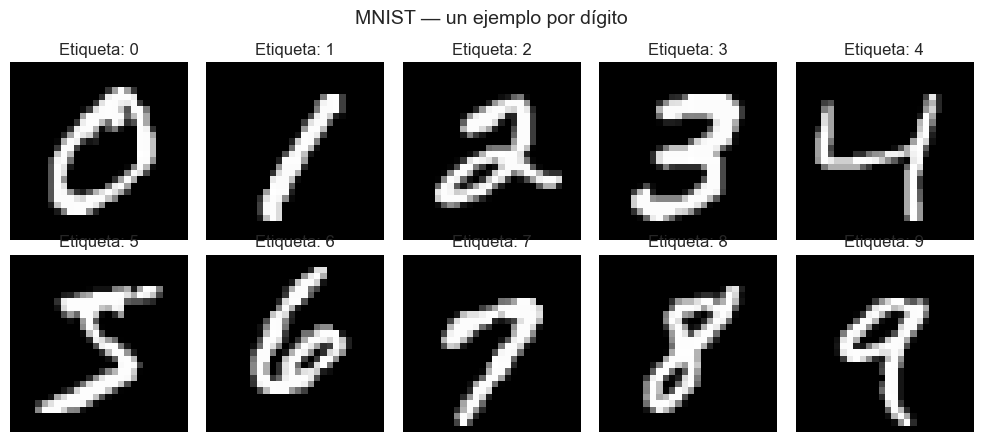

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.ravel()):
    idx = np.argmax(y_train_full == digit)   # primer ejemplo de cada dígito
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(f"Etiqueta: {digit}")
    ax.axis("off")
fig.suptitle("MNIST — un ejemplo por dígito", fontsize=14)
plt.tight_layout()
plt.show()

**Distribución de clases** — comprobamos que el dataset esté balanceado:

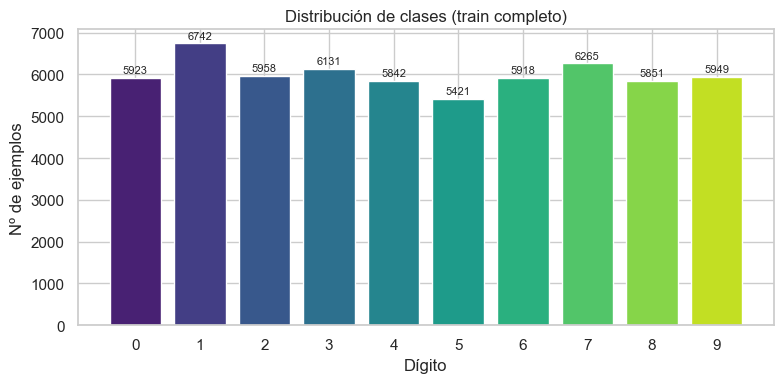

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
classes, counts = np.unique(y_train_full, return_counts=True)
bars = ax.bar(classes, counts, color=sns.color_palette("viridis", 10))
ax.set_xticks(classes)
ax.set_xlabel("Dígito"); ax.set_ylabel("Nº de ejemplos")
ax.set_title("Distribución de clases (train completo)")
ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Preprocesamiento y separación train / validación / test

1. **Normalizar** los píxeles a $[0,1]$ (dividir entre 255) — requisito de la diapositiva.
2. **Aplanar** cada imagen $28\times28 \rightarrow 784$ (la entrada de un MLP es un vector).
3. **Separar** el train completo en **entrenamiento (90%)** y **validación (10%)** de forma estratificada. El **test** se reserva intacto para la evaluación final.

In [5]:
# 1 + 2: normalizar a [0,1] y aplanar a vectores de 784
x_train_full_flat = (x_train_full.astype("float32") / 255.0).reshape(-1, 28 * 28)
x_test_flat       = (x_test.astype("float32")       / 255.0).reshape(-1, 28 * 28)

# 3: split estratificado train / validación
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full_flat, y_train_full,
    test_size=0.10, stratify=y_train_full, random_state=SEED,
)

print(f"Entrenamiento: {x_train.shape[0]:>6} ejemplos  -> {x_train.shape}")
print(f"Validación:    {x_val.shape[0]:>6} ejemplos  -> {x_val.shape}")
print(f"Test:          {x_test_flat.shape[0]:>6} ejemplos  -> {x_test_flat.shape}")

Entrenamiento:  54000 ejemplos  -> (54000, 784)
Validación:      6000 ejemplos  -> (6000, 784)
Test:           10000 ejemplos  -> (10000, 784)


### 7.4 Construcción del modelo (DFFNN)

Arquitectura *feed-forward* con dos capas ocultas y **Dropout** para regularizar (diapositiva pág. 37):

```
Entrada (784) → Dense(128, ReLU) → Dropout(0.3)
              → Dense(64,  ReLU) → Dropout(0.3)
              → Dense(10,  Softmax)   # 10 clases
```

- **ReLU** introduce la no linealidad en las capas ocultas.
- **Softmax** convierte la salida en una distribución de probabilidad sobre los 10 dígitos.

In [6]:
def build_model(dropout=0.3):
    model = keras.Sequential([
        keras.Input(shape=(28 * 28,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(10, activation="softmax"),
    ], name="FFNN_MNIST")
    return model

model = build_model(dropout=0.3)
model.summary()

Model: "FFNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 7.5 Compilación

- **Optimizador**: `Adam` (learning rate adaptativo).
- **Pérdida**: `sparse_categorical_crossentropy` (etiquetas enteras 0–9).
- **Métrica**: `accuracy`.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

### 7.6 Entrenamiento — *training iterations*

Entrenamos por **épocas** en mini-lotes (`batch_size=128`). Añadimos **Early Stopping** (diapositiva pág. 38): detiene el entrenamiento si la pérdida de validación deja de mejorar, restaurando los mejores pesos.

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1,
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=2,
)

print(f"\nÉpocas ejecutadas: {len(history.history['loss'])}")

Epoch 1/30
422/422 - 2s - 4ms/step - accuracy: 0.8332 - loss: 0.5441 - val_accuracy: 0.9378 - val_loss: 0.2076
Epoch 2/30
422/422 - 1s - 2ms/step - accuracy: 0.9300 - loss: 0.2406 - val_accuracy: 0.9558 - val_loss: 0.1518
Epoch 3/30
422/422 - 1s - 2ms/step - accuracy: 0.9444 - loss: 0.1918 - val_accuracy: 0.9593 - val_loss: 0.1348
Epoch 4/30
422/422 - 1s - 2ms/step - accuracy: 0.9524 - loss: 0.1599 - val_accuracy: 0.9680 - val_loss: 0.1145
Epoch 5/30
422/422 - 1s - 2ms/step - accuracy: 0.9574 - loss: 0.1433 - val_accuracy: 0.9683 - val_loss: 0.1100
Epoch 6/30
422/422 - 1s - 2ms/step - accuracy: 0.9626 - loss: 0.1256 - val_accuracy: 0.9730 - val_loss: 0.1028
Epoch 7/30
422/422 - 1s - 2ms/step - accuracy: 0.9651 - loss: 0.1177 - val_accuracy: 0.9723 - val_loss: 0.0980
Epoch 8/30
422/422 - 1s - 2ms/step - accuracy: 0.9678 - loss: 0.1048 - val_accuracy: 0.9727 - val_loss: 0.0937
Epoch 9/30
422/422 - 1s - 2ms/step - accuracy: 0.9698 - loss: 0.0998 - val_accuracy: 0.9743 - val_loss: 0.0895
E

### 7.7 Curvas de aprendizaje (loss y accuracy por época)

Comparamos **train vs validación**: si la validación empeora mientras el train mejora, hay *overfitting*.

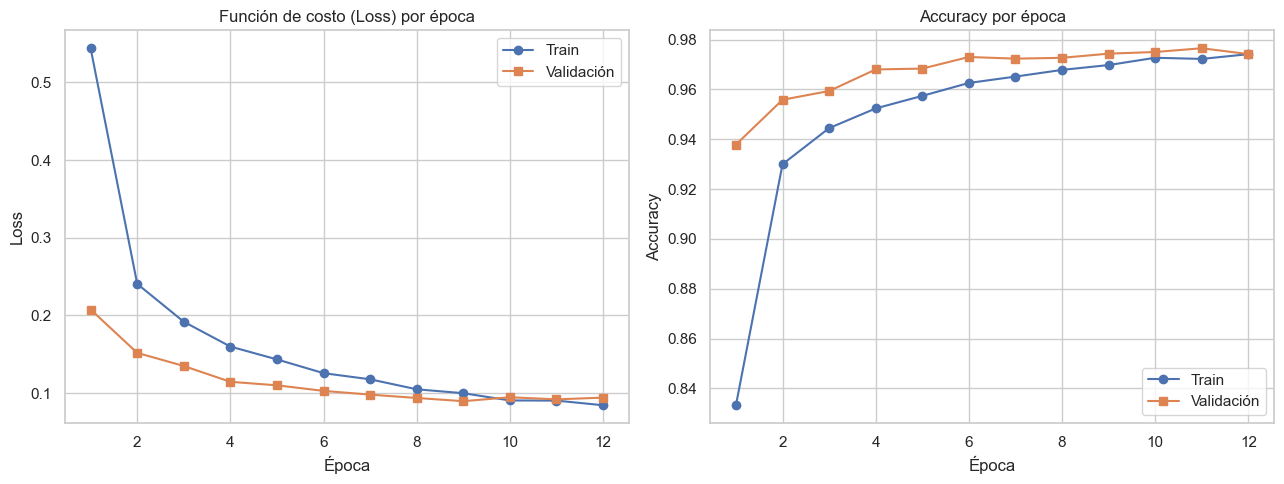

In [9]:
hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, hist["loss"], "o-", label="Train")
axes[0].plot(epochs_range, hist["val_loss"], "s-", label="Validación")
axes[0].set_title("Función de costo (Loss) por época")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(epochs_range, hist["accuracy"], "o-", label="Train")
axes[1].plot(epochs_range, hist["val_accuracy"], "s-", label="Validación")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

### 7.8 Evaluación final sobre el conjunto de test

El test **no** se usó durante el entrenamiento → estima la generalización real.

In [10]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test  loss:     {test_loss:.4f}")
print(f"Test  accuracy: {test_acc:.4f}  ({test_acc*100:.2f} %)")

# Predicciones
y_proba = model.predict(x_test_flat, verbose=0)
y_pred = y_proba.argmax(axis=1)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

Test  loss:     0.0781
Test  accuracy: 0.9759  (97.59 %)

Classification report:

              precision    recall  f1-score   support

           0     0.9838    0.9918    0.9878       980
           1     0.9868    0.9877    0.9872      1135
           2     0.9730    0.9787    0.9758      1032
           3     0.9620    0.9762    0.9690      1010
           4     0.9776    0.9766    0.9771       982
           5     0.9773    0.9664    0.9718       892
           6     0.9751    0.9802    0.9776       958
           7     0.9794    0.9698    0.9746      1028
           8     0.9642    0.9682    0.9662       974
           9     0.9788    0.9613    0.9700      1009

    accuracy                         0.9759     10000
   macro avg     0.9758    0.9757    0.9757     10000
weighted avg     0.9759    0.9759    0.9759     10000



### 7.9 Matriz de confusión

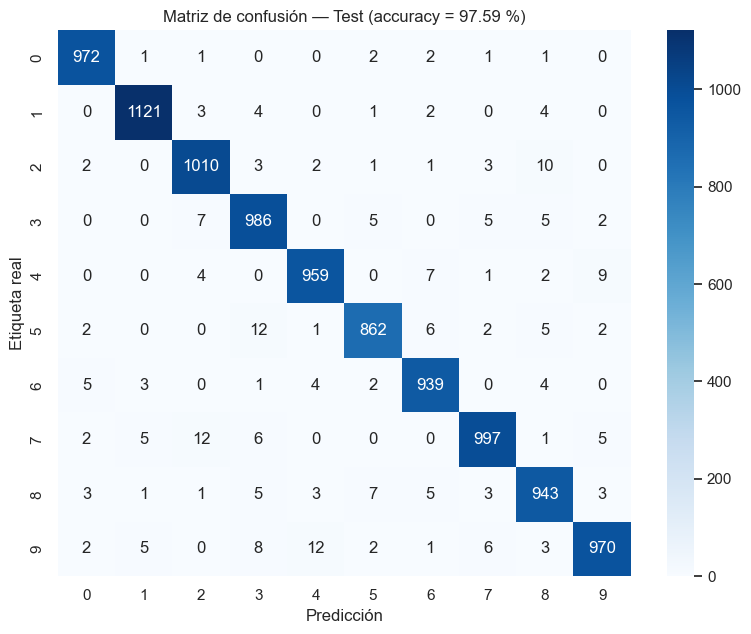

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
ax.set_title(f"Matriz de confusión — Test (accuracy = {test_acc*100:.2f} %)")
plt.tight_layout()
plt.show()

### 7.10 Visualización de predicciones

Mostramos ejemplos del test con su predicción (verde = acierto, rojo = error).

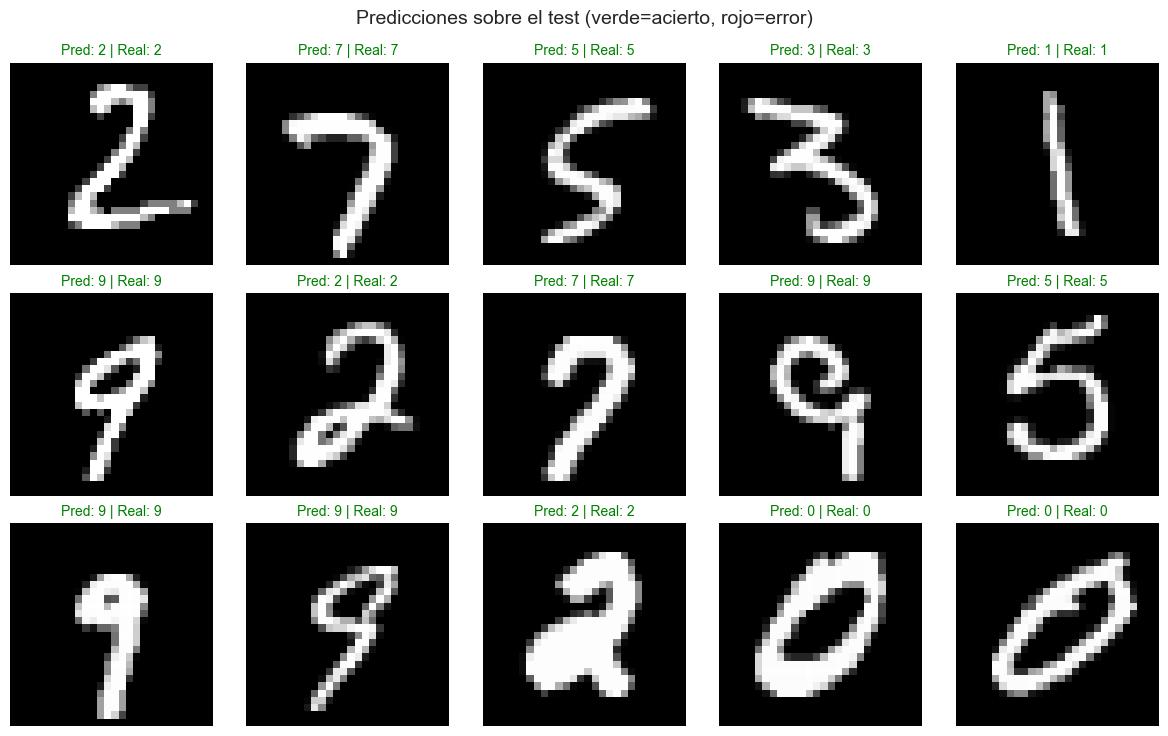

In [12]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_test), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(12, 7.5))
for ax, i in zip(axes.ravel(), sample_idx):
    ax.imshow(x_test[i], cmap="gray")
    ok = y_pred[i] == y_test[i]
    color = "green" if ok else "red"
    ax.set_title(f"Pred: {y_pred[i]} | Real: {y_test[i]}", color=color, fontsize=10)
    ax.axis("off")
fig.suptitle("Predicciones sobre el test (verde=acierto, rojo=error)", fontsize=14)
plt.tight_layout()
plt.show()

**Ejemplos mal clasificados** — los errores más comunes del modelo:

Total de errores en test: 241 de 10000 (2.41 %)


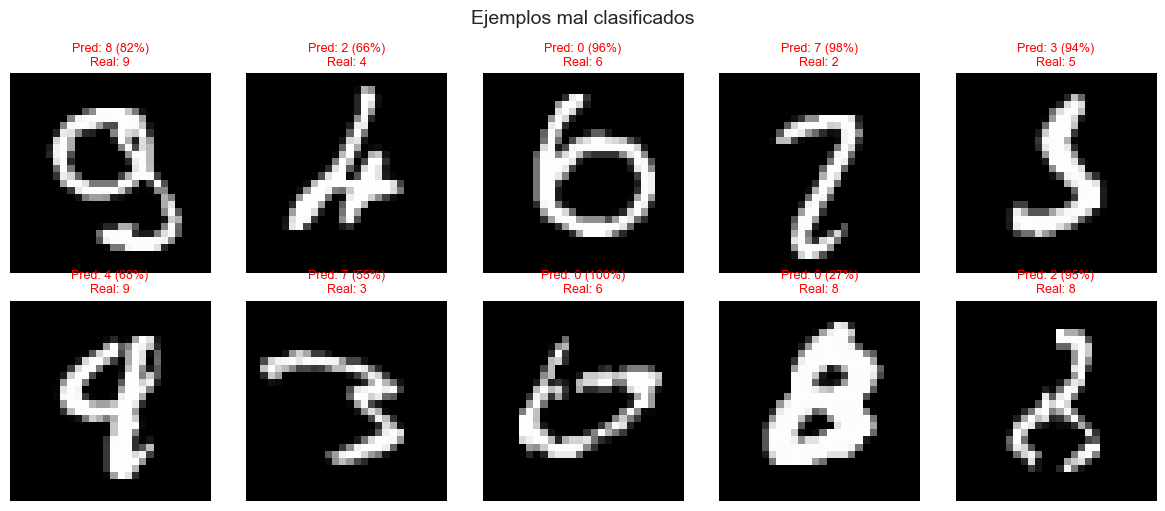

In [13]:
errors = np.where(y_pred != y_test)[0]
print(f"Total de errores en test: {len(errors)} de {len(y_test)} "
      f"({len(errors)/len(y_test)*100:.2f} %)")

n_show = min(10, len(errors))
sel = errors[:n_show]
fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for ax, i in zip(axes.ravel(), sel):
    ax.imshow(x_test[i], cmap="gray")
    conf = y_proba[i, y_pred[i]] * 100
    ax.set_title(f"Pred: {y_pred[i]} ({conf:.0f}%)\nReal: {y_test[i]}",
                 color="red", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[n_show:]:
    ax.axis("off")
fig.suptitle("Ejemplos mal clasificados", fontsize=14)
plt.tight_layout()
plt.show()

### 7.11 Demostración: Overfitting y Regularización

Para ilustrar las diapositivas 35–38, entrenamos **sin regularización** (sin Dropout, sin Early Stopping) y comparamos sus curvas con el modelo regularizado. Se espera ver que el modelo sin regularizar **memoriza** el train (gap train–validación mayor).

In [14]:
model_plain = build_model(dropout=0.0)
model_plain.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_plain = model_plain.fit(
    x_train, y_train, validation_data=(x_val, y_val),
    epochs=30, batch_size=128, verbose=0,   # sin early stopping
).history
print("Entrenamiento sin regularización completado:",
      len(hist_plain["loss"]), "épocas")

Entrenamiento sin regularización completado: 30 épocas


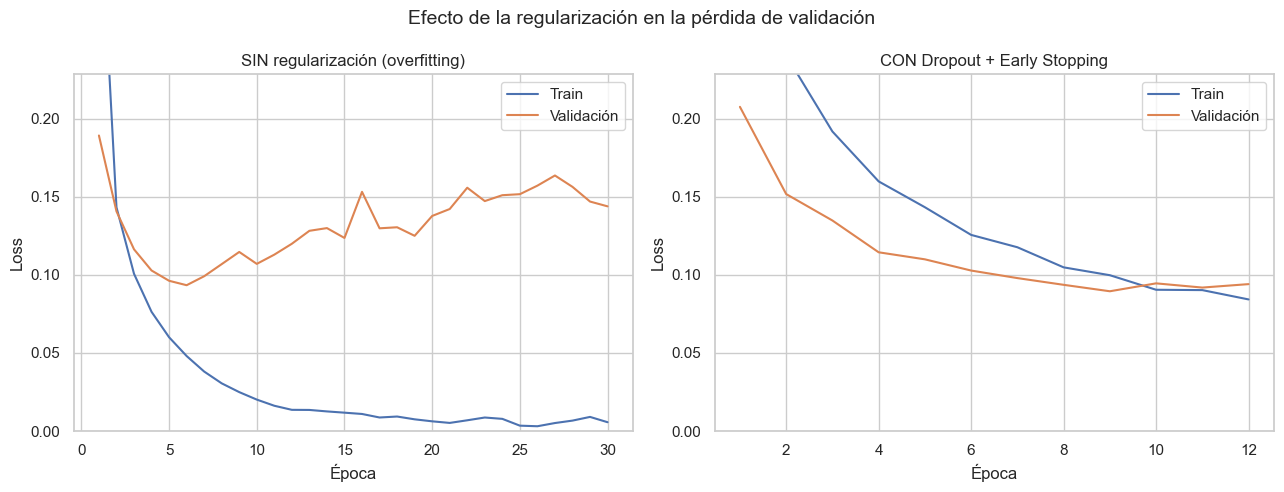

Gap (val_loss - train_loss) SIN regularización: 0.1382
Gap (val_loss - train_loss) CON regularización: 0.0098


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sin regularización
e1 = range(1, len(hist_plain["loss"]) + 1)
axes[0].plot(e1, hist_plain["loss"], label="Train")
axes[0].plot(e1, hist_plain["val_loss"], label="Validación")
axes[0].set_title("SIN regularización (overfitting)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend()

# Con regularización (modelo principal)
axes[1].plot(epochs_range, hist["loss"], label="Train")
axes[1].plot(epochs_range, hist["val_loss"], label="Validación")
axes[1].set_title("CON Dropout + Early Stopping")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss"); axes[1].legend()

# Mismo eje Y para comparar
ymax = max(max(hist_plain["val_loss"]), max(hist["val_loss"])) * 1.1
for ax in axes:
    ax.set_ylim(0, ymax)
fig.suptitle("Efecto de la regularización en la pérdida de validación", fontsize=14)
plt.tight_layout()
plt.show()

gap_plain = hist_plain["val_loss"][-1] - hist_plain["loss"][-1]
gap_reg = hist["val_loss"][-1] - hist["loss"][-1]
print(f"Gap (val_loss - train_loss) SIN regularización: {gap_plain:.4f}")
print(f"Gap (val_loss - train_loss) CON regularización: {gap_reg:.4f}")

## 8. Conclusión

- Implementamos una **Feed Forward Neural Network (MLP)** con **TensorFlow / Keras** y la entrenamos sobre **MNIST**.
- Aplicamos el flujo completo: normalización a $[0,1]$, **separación train / validación / test**, construcción del modelo, **entrenamiento por épocas** (*training iterations*) con **Backpropagation + Adam**, y evaluación.
- El modelo alcanza una **accuracy de test alta (~97–98 %)** con una arquitectura sencilla.
- Las **curvas de aprendizaje** y la sección 7.11 ilustran el **overfitting** y cómo **Dropout + Early Stopping** mejoran la generalización (diapositivas 35–38).
- La **matriz de confusión** muestra que los errores se concentran en dígitos visualmente parecidos (p. ej. 4↔9, 3↔5, 7↔1).

### Posibles mejoras
- Usar una **CNN** (Conv2D) en lugar de un MLP para explotar la estructura espacial de las imágenes.
- Probar otros optimizadores (`SGD`, `RMSProp`) y *learning rates*.
- Ajuste de hiperparámetros (nº de capas, neuronas, dropout) y *data augmentation*.